# Car Resale Price Model

Reads the curated zone produced by the event driven ETL pipeline, trains a model that deliberately
underestimates the selling price, and measures what that bias costs in accuracy.

Business requirement: the company wants to clear current inventory quickly, so a quote landing
slightly below the eventual sale price is preferable to one landing above it.

The pipeline that produced the input is S3 landing zone to SQS to Lambda to S3 curated zone,
provisioned by Terraform in `../terraform` and runnable against either real AWS or floci.

## 1. Setup

In [1]:
import io
import os

import boto3
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_pinball_loss, r2_score, root_mean_squared_error
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder

pd.set_option("display.width", 200)

RANDOM_STATE = 0
ALPHA = 0.25
N_SPLITS = 5

## 2. Read the curated zone

The same client code reaches real AWS or floci. When `AWS_ENDPOINT_URL` is set boto3 talks to the
emulator, and when it is absent `None` makes boto3 resolve real AWS through its normal credential
chain.

Set `CURATED_ZONE_BUCKET` to skip discovery, or take it from `terraform output curated_bucket`.

In [2]:
endpoint_url = os.environ.get("AWS_ENDPOINT_URL") or None
s3 = boto3.client("s3", endpoint_url=endpoint_url)

curated_bucket = os.environ.get("CURATED_ZONE_BUCKET")
if not curated_bucket:
    candidates = [b["Name"] for b in s3.list_buckets()["Buckets"] if "curated" in b["Name"]]
    if not candidates:
        raise RuntimeError("no curated bucket found, deploy the pipeline first")
    curated_bucket = candidates[0]

listing = s3.list_objects_v2(Bucket=curated_bucket, Prefix="curated_object/").get("Contents", [])
if not listing:
    raise RuntimeError("curated zone is empty, upload a csv to the landing zone first")

latest = max(listing, key=lambda obj: obj["LastModified"])
body = s3.get_object(Bucket=curated_bucket, Key=latest["Key"])["Body"].read()
df = pd.read_csv(io.BytesIO(body))

print("endpoint :", endpoint_url or "real aws")
print("bucket   :", curated_bucket)
print("key      :", latest["Key"])
print("shape    :", df.shape)
df.head()

endpoint : http://localhost:4566
bucket   : car-sales-local-curated-30a76bd7
key      : curated_object/ingest_date=2026-08-17/ml_sample_data_snapsoft.csv
shape    : (235, 23)


,brand,CarName,saledate,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,carheight,curbweight,cylindernumber,enginesize,compressionratio,horsepower,peakrpm,citympg,highwaympg,Price
0,toyota,toyota corolla,2016-11-23,diesel,std,four,hatchback,fwd,front,95.7,...,52.8,2275,4.0,110,22.5,56.0,4500,38,47,7788.0
1,toyota,toyota carina,2020-08-11,gas,std,four,wagon,4wd,front,95.7,...,59.1,3110,4.0,92,9.0,62.0,4800,27,32,8778.0
2,toyota,toyota corolla,2018-06-26,gas,std,two,hatchback,rwd,front,98.4,...,52.0,2714,4.0,146,9.3,116.0,4800,24,30,11549.0
3,toyota,toyota corona,2018-07-24,gas,std,two,hatchback,rwd,front,102.9,...,52.0,3016,6.0,171,9.3,161.0,5200,19,24,15998.0
4,nissan,nissan otti,2022-02-10,gas,std,four,sedan,fwd,front,100.4,...,55.1,3060,6.0,181,9.0,152.0,5200,19,25,13499.0


## 3. Verify the ETL contract

Assert rather than assume. The curated zone is the trust boundary, so it must contain no personal
data, and it must still contain the rows whose gaps are imputable.

In [3]:
PII_COLUMNS = {"car_ID", "ownername", "owneremail", "dealershipaddress", "iban"}

leaked = PII_COLUMNS & set(df.columns)
assert not leaked, f"pii leaked into the curated zone: {sorted(leaked)}"
assert df["Price"].notna().all(), "target column has missing values"

print("rows                  :", len(df))
print("columns               :", len(df.columns))
print("pii columns present   :", sorted(leaked) or "none")
print("null cells retained   :", int(df.isna().sum().sum()))
df.isna().sum().loc[lambda s: s > 0]

rows                  : 235
columns               : 23
pii columns present   : none
null cells retained   : 21


enginelocation    9
carlength         4
cylindernumber    8
dtype: int64

## 4. Feature selection

Four columns are dropped as features here rather than in the Lambda, because they can legally be
used but were measured not to help. Keeping them in the curated zone means an analyst can still
query them.

Measured cross validated change in MAE when each is added to the base feature set, where a positive
number means the column makes the model worse:

| column | evidence | delta MAE |
|---|---|---|
| color | ANOVA p 0.79, mutual information 0.000 | +43.8 |
| doornumber | ANOVA p 0.75, redundant with carbody | +2.1 |
| saledate | spearman 0.060 p 0.36, no temporal drift | +50.2 as year, +95.5 as ordinal |
| CarName | 147 distinct values in 245 rows, too sparse | replaced by derived brand |

`compressionratio` and `peakrpm` are kept for the same reason inverted: they measurably help, by
20.9 and 29.0 MAE respectively, despite weak univariate correlations.

In [4]:
DROPPED_AS_FEATURES = ["CarName", "color", "doornumber", "saledate"]

CATEGORICAL = ["brand", "fueltype", "aspiration", "carbody", "drivewheel", "enginelocation"]
NUMERIC = [
    "wheelbase", "carlength", "carwidth", "carheight", "curbweight",
    "cylindernumber", "enginesize", "compressionratio", "horsepower",
    "peakrpm", "citympg", "highwaympg",
]

X = df[CATEGORICAL + NUMERIC].copy()
for column in CATEGORICAL:
    X[column] = X[column].astype("string").fillna("__MISSING__").astype(str)

y = df["Price"].to_numpy(float)

print("dropped as features :", DROPPED_AS_FEATURES)
print("categorical         :", len(CATEGORICAL))
print("numeric             :", len(NUMERIC))
print("design matrix       :", X.shape)

dropped as features : ['CarName', 'color', 'doornumber', 'saledate']
categorical         : 6
numeric             : 12
design matrix       : (235, 18)


## 5. Model

Imputation lives inside the pipeline on purpose. `SimpleImputer` is then fitted on training folds
only, so no statistic from the held out fold leaks into training. This is also why the Lambda left
those cells empty instead of filling them.

`HistGradientBoostingRegressor` can handle missing values natively, so the imputer is not strictly
required. It is explicit because the brief asks that imputable rows be retained and imputed, and an
inspectable imputation step is a better answer than silently relying on the estimator.

Categoricals are ordinal encoded and declared with `categorical_features`, which gives the model
native categorical splits. One hot encoding `brand`, which has over twenty levels, would scatter the
signal across sparse columns at only 235 rows.

In [5]:
def build_model(**overrides):
    preprocessor = ColumnTransformer([
        ("categorical", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), CATEGORICAL),
        ("numeric", SimpleImputer(strategy="median"), NUMERIC),
    ])

    params = dict(
        max_iter=400,
        learning_rate=0.06,
        max_leaf_nodes=15,
        min_samples_leaf=5,
        l2_regularization=1.0,
        categorical_features=list(range(len(CATEGORICAL))),
        random_state=RANDOM_STATE,
    )
    params.update(overrides)

    return Pipeline([("preprocess", preprocessor), ("model", HistGradientBoostingRegressor(**params))])


cv = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
build_model()

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default

## 6. Evaluation metrics

`OverpredictionRate` is the metric that encodes the business requirement: the fraction of quotes
that land above the eventual sale price. A neutral regressor sits near 0.50, and the company wants
it below that.

`MeanSignedError` shows the direction and size of the bias in currency units, so the tilt is visible
rather than inferred.

In [6]:
def evaluate(y_true, y_pred, alpha=ALPHA):
    residual = y_pred - y_true
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": root_mean_squared_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
        "MedAPE": float(np.median(np.abs(residual) / y_true)),
        "OverpredictionRate": float(np.mean(y_pred > y_true)),
        "MeanSignedError": float(np.mean(residual)),
        "PinballLoss": mean_pinball_loss(y_true, y_pred, alpha=alpha),
    }

## 7. Neutral model versus tilted model

Both are scored with `cross_val_predict` against the same `cv` object, so every prediction is out of
fold and the two models see identical splits. The difference is therefore attributable to the loss
function rather than to a favourable split.

In [7]:
neutral_pred = cross_val_predict(build_model(loss="squared_error"), X, y, cv=cv)
tilted_pred = cross_val_predict(build_model(loss="quantile", quantile=ALPHA), X, y, cv=cv)

comparison = pd.DataFrame({
    "neutral (squared error)": evaluate(y, neutral_pred),
    f"tilted (quantile alpha={ALPHA})": evaluate(y, tilted_pred),
}).T

comparison.round(4)

,MAE,RMSE,R2,MedAPE,OverpredictionRate,MeanSignedError,PinballLoss
neutral (squared error),1224.4430,2107.1146,0.9259,0.0507,0.4979,-42.4464,601.6099
tilted (quantile alpha=0.25),1408.4492,2295.6094,0.9121,0.0684,0.3957,-583.1123,558.4465


## 8. Stability at 235 rows

A single cross validation estimate on this little data is noisy. Repeating over several seeds shows
how much of any difference is real. Treat two models closer than roughly two standard deviations as
a tie.

In [8]:
records = []
for seed in range(5):
    folds = KFold(n_splits=N_SPLITS, shuffle=True, random_state=seed)
    for label, params in [("neutral", dict(loss="squared_error")),
                          ("tilted", dict(loss="quantile", quantile=ALPHA))]:
        prediction = cross_val_predict(build_model(**params), X, y, cv=folds)
        scores = evaluate(y, prediction)
        records.append({"seed": seed, "model": label,
                        "MAE": scores["MAE"],
                        "OverpredictionRate": scores["OverpredictionRate"]})

stability = pd.DataFrame(records).drop(columns=["seed"]).groupby("model").agg(["mean", "std"]).round(4)
stability

MAE          OverpredictionRate        
              mean      std               mean     std
model                                                 
neutral  1266.2119  30.2862             0.4970  0.0106
tilted   1373.2368  27.7617             0.3932  0.0111

## 9. The accuracy cost of underestimating

Sweeping alpha exposes the tradeoff instead of hiding it. Lowering alpha pushes predictions down and
reduces the overprediction rate, and it costs accuracy. The company can pick an operating point from
this table.

Below roughly alpha 0.15 the model stops being slightly conservative and simply becomes wrong, with
R2 collapsing from about 0.92.

In [9]:
sweep_rows = []
for alpha in [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    prediction = cross_val_predict(build_model(loss="quantile", quantile=alpha), X, y, cv=cv)
    scores = evaluate(y, prediction, alpha=alpha)
    sweep_rows.append({
        "alpha": alpha,
        "OverpredictionRate": scores["OverpredictionRate"],
        "MAE": scores["MAE"],
        "RMSE": scores["RMSE"],
        "R2": scores["R2"],
        "MeanSignedError": scores["MeanSignedError"],
    })

sweep = pd.DataFrame(sweep_rows)
sweep.round(4)

,alpha,OverpredictionRate,MAE,RMSE,R2,MeanSignedError
0,0.05,0.2213,3125.0038,6156.9737,0.3674,-2861.2918
1,0.10,0.3021,1902.4037,3427.9972,0.8039,-1421.9055
2,0.15,0.3617,1615.4928,2765.8483,0.8724,-989.2810
3,0.20,0.3660,1563.4885,2723.6454,0.8762,-839.6918
4,0.25,0.3957,1408.4492,2295.6094,0.9121,-583.1123
5,0.30,0.4255,1331.6773,2061.7121,0.9291,-437.9337
6,0.35,0.4170,1301.3944,2042.0183,0.9304,-411.6621
7,0.40,0.4383,1260.1739,1988.5252,0.9340,-309.2927
8,0.45,0.4723,1254.4727,1924.1832,0.9382,-170.9631
9,0.50,0.4894,1181.2069,1853.0545,0.9427,-131.6092


Text(0.5, 1.0, 'Accuracy cost of underestimating, chosen alpha 0.25')

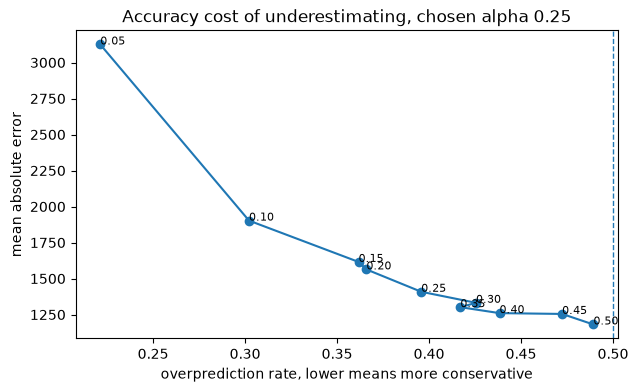

In [10]:
axis = sweep.plot(x="OverpredictionRate", y="MAE", marker="o", legend=False, figsize=(7, 4))
for _, row in sweep.iterrows():
    axis.annotate(f"{row['alpha']:.2f}", (row["OverpredictionRate"], row["MAE"]), fontsize=8)
axis.axvline(0.5, linestyle="--", linewidth=1)
axis.set_xlabel("overprediction rate, lower means more conservative")
axis.set_ylabel("mean absolute error")
axis.set_title(f"Accuracy cost of underestimating, chosen alpha {ALPHA}")

## 10. Residual behaviour

The tilted model should sit mostly below the diagonal, which is the requirement made visible.

Text(0.5, 1.0, 'Points below the line are underestimates, which is the goal')

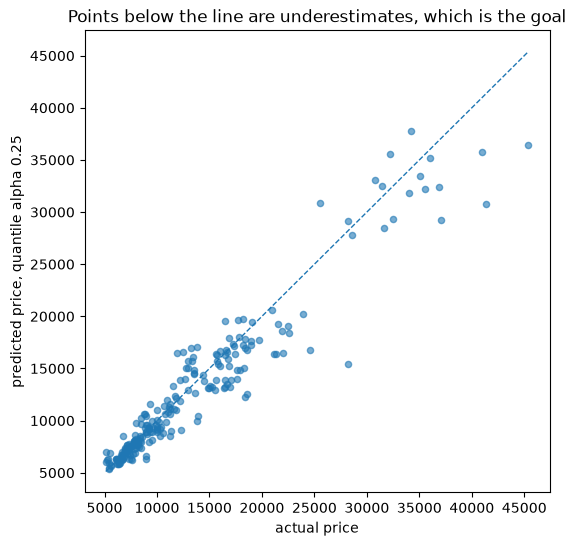

In [11]:
figure_axes = pd.DataFrame({"actual": y, "neutral": neutral_pred, "tilted": tilted_pred}).plot.scatter(
    x="actual", y="tilted", figsize=(6, 6), alpha=0.6)
limits = [y.min(), y.max()]
figure_axes.plot(limits, limits, linestyle="--", linewidth=1)
figure_axes.set_xlabel("actual price")
figure_axes.set_ylabel(f"predicted price, quantile alpha {ALPHA}")
figure_axes.set_title("Points below the line are underestimates, which is the goal")

## 11. What drives the prediction

Permutation importance is measured on the fitted final model, scored by mean absolute error.

In [12]:
final_model = build_model(loss="quantile", quantile=ALPHA).fit(X, y)

importance = permutation_importance(
    final_model, X, y, n_repeats=10, random_state=RANDOM_STATE,
    scoring="neg_mean_absolute_error")

pd.DataFrame({
    "feature": X.columns,
    "importance": importance.importances_mean,
    "std": importance.importances_std,
}).sort_values("importance", ascending=False).head(12).round(2)

,feature,importance,std
10,curbweight,2073.55,158.04
12,enginesize,1634.93,90.68
14,horsepower,977.13,73.95
8,carwidth,608.73,52.87
17,highwaympg,451.20,36.99
4,drivewheel,262.85,32.60
16,citympg,237.22,21.89
9,carheight,198.37,15.54
6,wheelbase,195.58,25.87
15,peakrpm,184.24,16.27


## 12. Conclusion

The underestimation requirement is met by the training objective rather than by discounting a
neutral prediction. That matters because alpha is a single tunable dial with a measurable effect, so
the business can be told what fraction of quotes are expected to exceed the eventual sale price, and
that figure is a fitted property of the model rather than a hardcoded fudge factor.

Rejected alternative: multiply a neutral prediction by a constant below one. It reaches a similar
average bias, but it is not fitted, it cannot be tuned against a target rate, and it hides the
accuracy tradeoff from whoever has to sign off on it.

Deep learning was considered and rejected for this dataset. skorch and scikeras do expose PyTorch
and TensorFlow through the scikit-learn estimator API, so a neural network would drop into this same
pipeline and could carry a custom asymmetric loss. At 235 rows and 18 mostly tabular features,
gradient boosted trees are the stronger choice, they handle the categoricals and the missing values
natively, and they add no heavy dependency. skorch becomes worth revisiting if the dataset grows by
one to two orders of magnitude.